In [1]:
import torch
import torch.nn as nn
import torchvision
from torchvision.datasets import CelebA
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt 
import numpy as np 
from torchvision.datasets import ImageFolder


In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [8]:
import torchvision.transforms as transform

trans = transform.Compose([
    transform.Lambda(lambda img: img.convert("RGB")),  # fix RGBA -> RG
    transform.CenterCrop(178),
    transform.Resize(64),
    transform.ToTensor(),
    transform.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

In [9]:
import kagglehub
 
# Download latest version
path = kagglehub.dataset_download("jessicali9530/celeba-dataset")
 
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'celeba-dataset' dataset.
Path to dataset files: /kaggle/input/celeba-dataset


In [10]:
dataset = ImageFolder(
    root = '/root/.cache/kagglehub/datasets/jessicali9530/celeba-dataset/versions/2',
    transform = trans
)

dataloader = DataLoader(
    dataset,
    batch_size = 128,
    shuffle=True,
    num_workers=3
)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 3 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 3 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


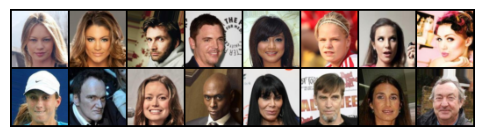

In [11]:
real_batch = next(iter(dataloader))
grid = torchvision.utils.make_grid(
    real_batch[0][:16],
    normalize=True
)

plt.figure(figsize=(6,6))
plt.imshow(grid.permute(1,2,0).cpu())
plt.axis('off')
plt.show()

- Upsampling => better resolution
- z_dim => the noise dims
- channels_img => my output
- 

In [19]:
class Generator(nn.Module):
    def __init__(self, z_dim=100, channels_img=3, features_g=64):
        super().__init__()

        self.net = nn.Sequential(
            self._block(z_dim, features_g*8, 4,1,0),
            self._block(features_g*8, features_g*4, 4,2,0),
            self._block(features_g*4, features_g*2, 4,2,1),
            self._block(features_g*2, features_g, 4,2,1),
            nn.ConvTranspose2d(features_g, channels_img, 4,2,1),
            nn.Tanh()

        )


    def _block(self, in_c, out_c, k, s, p):
        return nn.Sequential(
            nn.ConvTranspose2d(in_c, out_c, k, s, p, bias=False),
            nn.BatchNorm2d(out_c), #prevent shift distru => stabilize the model, won't collapse
            nn.ReLU(True),

        )

    def forward(self,x):
        return self.net(x)

In [ ]:
class Discriminator(nn.Module):
    #batch norm => problem with zeros => used leakyrelu t prevent any vanishing gradients\
    #leakyrelu => can't delete negative gradient, i need it => leakyrelu allows negative gradients
    #if removed => discreminator: dies neurons quickly, generator will use these dying neurons
    def __init__(self, channels_img=3, features_g=64):
        super().__init__()

        self.net = nn.Sequential(
            self._block(z_dim, features_g*8, 4,1,0),
            self._block(features_g, features_g*2, 4,2,0),
            self._block(features_g*2, features_g*4, 4,2,1),
            self._block(features_g*4, features_g*8, 4,2,1),
            nn.ConvTranspose2d(features_g, channels_img, 4,2,1),
            nn.Sigmoid()

        )

    def _block(self, in_c, out_c, k, s, p):
        return nn.Sequential(
            nn.ConvTranspose2d(in_c, out_c, k, s, p, bias=False),
            nn.BatchNorm2d(out_c), #prevent shift distru => stabilize the model, won't collapse
            nn.LeakyReLU(0.2),

        )

    def forward(self,x):
        return self.net(x).view(-1)

In [21]:
def initialize_weights(model):
    for m in model.modules():
        if isinstance(m, (nn.Conv2d, nn.LazyConvTranspose2d, nn.BatchNorm2d)):
            nn.init.normal_(m.weight.data, 0.0, 0.02)

In [22]:
z_dim = 100
gen = Generator(z_dim).to(device)
disc = Discriminator().to(device)

initialize_weights(gen)
initialize_weights(disc)

In [24]:
from torch import optim
criterion = nn.BCELoss()
opt_gen = optim.Adam(gen.parameters(), betas=(.5, .999))
opt_disc = optim.Adam(disc.parameters(), betas=(.5, .999))

In [ ]:
num_epochs = 50
noise = torch.randn(128, z_dim, 1,1)

for epoch in range(epochs):
        